# IA 2 — Séance 14 — Travail d'équipe 2
## Les clients de la banque

**Équipe 2** — Membres : *(nom, nom, …)*

### Répartition du travail

| Section | Responsable(s) |
|---|---|
| 1. Découvrir les données | toute l'équipe |
| 2. Le supervisé : la référence | Iyadhy |
| 3. Le non supervisé : chercher sans étiquettes | Khaoula |
| 4. Le semi-supervisé : quelques étiquettes | |
| 5. Synthèse et conclusion | toute l'équipe |

### Règles du carnet

- Sous **chaque** question se trouve une cellule **Observation**. Elle doit être remplie, y compris après les questions de programmation : ce que vous voyez, ce que vous en concluez.
- Les endroits à compléter dans le code sont marqués `...`.
- Le carnet remis doit s'exécuter **du début à la fin** sans erreur (*Kernel → Restart & Run All*).
- La déclaration d'utilisation de l'IA, à la fin du carnet, est **obligatoire**.

## La situation

Une banque en ligne veut proposer des forfaits adaptés à ses clients. Elle dispose de six mesures sur **800 clients**. Pour ces 800 clients, un conseiller a rencontré chaque personne et noté son profil : **étudiant**, **famille**, **retraité** ou **commerçant**.

La banque a des millions d'autres clients jamais rencontrés. Elle veut savoir si l'IA peut retrouver ces profils toute seule, et combien de rencontres avec un conseiller sont vraiment nécessaires.

| Colonne | Signification |
|---|---|
| `age` | âge du client, en années |
| `revenu_annuel` | revenu annuel, en $ |
| `transactions_mois` | nombre de transactions par mois |
| `montant_moyen` | montant moyen d'une transaction, en $ |
| `achats_en_ligne_%` | part des achats faits en ligne, en % |
| `retraits_guichet_mois` | nombre de retraits au guichet par mois |

*Les données sont simulées, mais construites pour ressembler à une situation réelle.*

In [1]:
# Cellule de départ — exécutez-la sans la modifier.
%pip install matplotlib scikit-learn numpy
import warnings
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.semi_supervised import LabelSpreading
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Les données — exécutez cette cellule sans la modifier.
def _gen(spec, tailles, seed, arrondis):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for c, n in enumerate(tailles):
        cols = []
        for (moy, ec) in spec[c]:
            cols.append(rng.normal(moy, ec, n))
        X.append(np.column_stack(cols)); y.append(np.full(n, c))
    X = np.vstack(X); y = np.concatenate(y)
    ordre = rng.permutation(len(y))
    X, y = X[ordre], y[ordre]
    X = np.clip(X, 0, None)
    for j, d in enumerate(arrondis):
        X[:, j] = np.round(X[:, j], d)
    return X, y

def charger():
    colonnes = ["age", "revenu_annuel", "transactions_mois", "montant_moyen", "achats_en_ligne_%", "retraits_guichet_mois"]
    classes = ["etudiant", "famille", "retraite", "commercant"]
    spec = [
        [(23, 4), (22000, 9000), (48, 14), (30, 14), (68, 14), (1.2, 1.2)],
        [(41, 8), (78000, 22000), (62, 15), (75, 25), (48, 14), (2.0, 1.3)],
        [(68, 8), (42000, 13000), (30, 11), (55, 20), (20, 11), (5.0, 2.2)],
        [(45, 9), (92000, 28000), (85, 24), (115, 40), (42, 15), (3.2, 1.8)],
    ]
    X, y = _gen(spec, [250, 250, 150, 150], 41, [0, -2, 0, 0, 0, 0])
    X[:, 0] = np.clip(X[:, 0], 18, None)      # clients majeurs
    X[:, 4] = np.clip(X[:, 4], 0, 100)        # un pourcentage
    return X, y, colonnes, classes

X, y, colonnes, classes = charger()
print("Données chargées.")

Données chargées.


---
# 1. Découvrir les données
*Toute l'équipe, avant de se répartir les sections 2, 3 et 4.*

### Question 1.1 — Combien d'exemples, et de quelles classes ?
Complétez la cellule pour afficher le nombre d'exemples de chaque classe.

In [ ]:
print("forme de X :", X.shape)
print("colonnes   :", colonnes)
print()
for i, nom in enumerate(classes):
    nombre = np.sum(y == i)
    print(f"{nom:20s} : {nombre} exemples")

forme de X : (800, 6)
colonnes   : ['age', 'revenu_annuel', 'transactions_mois', 'montant_moyen', 'achats_en_ligne_%', 'retraits_guichet_mois']

etudiant             : Ellipsis exemples
famille              : Ellipsis exemples
retraite             : Ellipsis exemples
commercant           : Ellipsis exemples


**Observation 1.1 :**

Le jeu de données contient 800 clients répartis en quatre profils. Les classes ne sont pas parfaitement équilibrées : les étudiants et les familles sont les plus nombreux (250 chacun), tandis que les retraités et commerçants sont moins représentés (150 chacun). Cela pourrait influencer certains modèles supervisés, mais l’écart reste raisonnable.

### Question 1.2 — L'ordre de grandeur des mesures
Pour chaque colonne, affichez le minimum, la moyenne et le maximum.

In [5]:
for j, nom in enumerate(colonnes):
    colonne = X[:, j]
    mini = round(np.min(colonne), 1)
    moyenne = round(np.mean(colonne), 1)
    maxi = round(np.max(colonne), 1)
    print(f"{nom:24s} min = {mini:>10.1f}   moyenne = {moyenne:>10.1f}   max = {maxi:>10.1f}")

age                      min =       18.0   moyenne =       41.6   max =       85.0
revenu_annuel            min =     1600.0   moyenne =    56182.9   max =   177400.0
transactions_mois        min =        3.0   moyenne =       56.4   max =      140.0
montant_moyen            min =        0.0   moyenne =       63.8   max =      227.0
achats_en_ligne_%        min =        0.0   moyenne =       47.7   max =      100.0
retraits_guichet_mois    min =        0.0   moyenne =        2.5   max =        9.0


**Observation 1.2 :**

Les caractéristiques ont des échelles très différentes. Par exemple, l’âge varie de 18 à 85 alors que le revenu annuel varie de 1 600 à 177 400. Certaines variables comme les achats en ligne sont limitées entre 0 et 100 %, tandis que d’autres peuvent prendre des valeurs beaucoup plus grandes. Il faudra donc probablement mettre les variables à la même échelle avant d’utiliser un algorithme basé sur les distances comme K-Means.

### Question 1.3 — Un premier dessin
Choisissez deux colonnes et dessinez les exemples, une couleur par classe. Essayez **au moins trois paires** de colonnes ; gardez dans le carnet la paire qui sépare le mieux les classes, et dites dans l'observation quelles paires vous avez essayées.

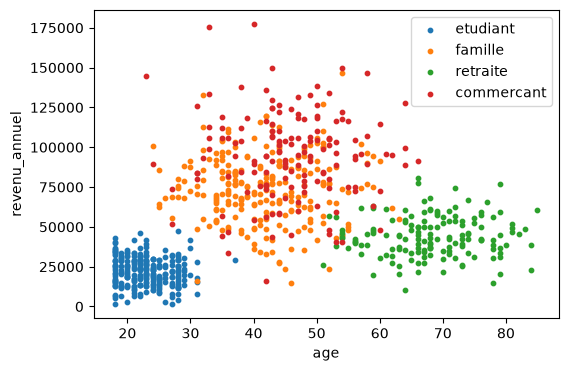

In [6]:
COL_X = "age"
COL_Y = "revenu_annuel"

jx, jy = colonnes.index(COL_X), colonnes.index(COL_Y)
plt.figure(figsize=(6, 4))
for i, nom in enumerate(classes):
    plt.scatter(X[y == i, jx], X[y == i, jy], s=10, label=nom)
plt.xlabel(COL_X)
plt.ylabel(COL_Y)
plt.legend()
plt.show()

**Observation 1.3 :**

Le graphique âge/revenu annuel sépare assez bien les étudiants et les retraités : les étudiants sont généralement plus jeunes avec un revenu plus faible, tandis que les retraités sont plus âgés avec un revenu moyen. En revanche, les familles et les commerçants se chevauchent beaucoup, donc ces deux caractéristiques ne suffisent pas à bien les distinguer.

---
# 2. Le supervisé : la référence
On commence par le cas le plus confortable : **toutes** les étiquettes sont connues. Le résultat servira de point de comparaison pour la suite.

### Question 2.1 — Séparer l'entraînement et le test
Gardez 30 % des exemples pour le test, avec `random_state=0`.

In [ ]:
X_train, X_test, y_train, y_test = ...
print(len(X_train), "exemples pour entraîner,", len(X_test), "pour tester")

**Observation 2.1 :**

*Votre réponse ici.*

### Question 2.2 — Un arbre de décision, puis une forêt
Entraînez un arbre de décision et une forêt aléatoire (`random_state=0` pour les deux), puis calculez leur note sur le test.

In [ ]:
arbre = ...
arbre.fit(X_train, y_train)
note_arbre = round(100 * arbre.score(X_test, y_test), 1)

foret = ...
...
note_foret = round(100 * foret.score(X_test, y_test), 1)

print("arbre :", note_arbre, "%")
print("forêt :", note_foret, "%")

**Observation 2.2 :**

*Votre réponse ici.*

### Question 2.3 — Classe par classe
Une seule note cache parfois des différences. Complétez la fonction pour afficher, pour chaque classe, la part des exemples du test bien reconnus par la forêt.

In [ ]:
def par_classe(modele, X_t, y_t):
    pred = modele.predict(X_t)
    for i, nom in enumerate(classes):
        bons = ...
        print(f"{nom:20s} : {round(100 * bons, 1)} % bien reconnus")

par_classe(foret, X_test, y_test)

**Observation 2.3 :**

*Votre réponse ici.*

### Question 2.4 — Le prix des étiquettes
Une rencontre avec un conseiller dure environ **45 minutes**. Combien d'heures de travail ont coûté les étiquettes utilisées pour entraîner la forêt ? Faites le calcul dans la cellule, puis commentez : ce coût est-il réaliste si la banque veut étiqueter des milliers d'exemples de plus ?

In [ ]:
MINUTES_PAR_EXEMPLE = 45
heures = ...
print("coût des étiquettes d'entraînement :", round(heures, 1), "heures")

**Observation 2.4 :**

*Votre réponse ici.*

---
# 3. Le non supervisé : chercher sans étiquettes
Dans cette section, **les modèles ne voient jamais `y`**. On ne s'en sert qu'après coup, pour vérifier ce qu'ils ont trouvé.

### Question 3.1 — K-Means sur les mesures brutes
Lancez K-Means avec autant de groupes que de classes, sur `X` tel quel, puis regardez ce que contient chaque groupe.

In [ ]:
def contenu(groupes, k):
    for g in range(k):
        noms = [classes[i] for i in y[groupes == g]]          # y sert seulement à vérifier
        print(f"groupe {g} : {len(noms):4d} exemples ->", dict(Counter(noms)))

K = len(classes)
km_brut = KMeans(n_clusters=K, n_init=10, random_state=0)
groupes_brut = ...
contenu(groupes_brut, K)

**Observation 3.1 :**

*Votre réponse ici.*

### Question 3.2 — K-Means après mise à l'échelle
Mettez toutes les mesures à la même échelle avec `StandardScaler`, puis relancez exactement le même K-Means.

In [ ]:
X_echelle = ...
groupes = ...
contenu(groupes, K)

**Observation 3.2 :**

*Votre réponse ici.*

### Question 3.3 — Combien de groupes ? Le coude
Calculez l'inertie de K-Means pour $k$ = 1 à 8 sur les données mises à l'échelle, et dessinez la courbe.

In [ ]:
valeurs = []
for k in range(1, 9):
    modele = ...
    valeurs.append(round(modele.inertia_))
print("inerties pour k = 1 à 8 :", valeurs)

plt.figure(figsize=(5, 3))
plt.plot(range(1, 9), valeurs, marker="o")
plt.xlabel("nombre de groupes k")
plt.ylabel("inertie")
plt.show()

**Observation 3.3 :**

*Votre réponse ici.*

### Question 3.4 — 3 ou 4 groupes ?
La banque veut **quatre** forfaits. Lancez K-Means avec 3 groupes, puis avec 4, et comparez leur contenu.

In [ ]:
for k in [3, 4]:
    print(f"--- k = {k}")
    g_k = ...
    contenu(g_k, k)

**Observation 3.4 :**

*Votre réponse ici.*

### Question 3.5 — Décrire les groupes avec des mots
Choisissez votre nombre de groupes `K_CHOISI` et justifiez-le dans l'observation. Affichez ensuite la **moyenne de chaque mesure** dans chaque groupe, dans les unités d'origine. Donnez enfin un **nom** à chaque groupe, comme si vous le présentiez à la banque.

In [ ]:
K_CHOISI = ...
groupes_choisis = KMeans(n_clusters=K_CHOISI, n_init=10, random_state=0).fit_predict(X_echelle)
contenu(groupes_choisis, K_CHOISI)
print()
for g in range(K_CHOISI):
    moyennes = ...        # les mesures d'origine, pas X_echelle
    print(f"groupe {g} :", {nom: round(float(v), 1) for nom, v in zip(colonnes, moyennes)})

| Groupe | Nom que vous lui donnez | Ce qui le caractérise |
|---|---|---|
| 0 | | |
| 1 | | |
| … | | |

**Observation 3.5 :**

*Votre réponse ici.*

### Question 3.6 — Voir les données avec l'ACP
Réduisez les mesures mises à l'échelle à **2 composantes**, affichez la part de l'information gardée, puis dessinez les exemples deux fois côte à côte : colorés par les groupes de K-Means, puis par les vraies classes.

In [ ]:
acp = ...
deux = acp.fit_transform(X_echelle)
garde = ...
print("information gardée :", garde, "%")

couleurs = np.array(["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(deux[:, 0], deux[:, 1], c=couleurs[groupes_choisis], s=10)
axes[0].set_title("Groupes de K-Means (sans étiquettes)")
axes[1].scatter(deux[:, 0], deux[:, 1], c=couleurs[y], s=10)
axes[1].set_title("Vraies classes (ajoutées après coup)")
for a in axes:
    a.set_xlabel("composante 1")
    a.set_ylabel("composante 2")
plt.show()

**Observation 3.6 :**

*Votre réponse ici.*

### Question 3.7 — L'ACP devant un client
Un client se voit refuser une carte de crédit par un modèle entraîné sur les 2 composantes de l'ACP. Il demande pourquoi. Que pouvez-vous lui répondre ? Répondez dans l'observation.

**Observation 3.7 :**

*Votre réponse ici.*

---
# 4. Le semi-supervisé : quelques étiquettes seulement
On revient à la situation réaliste : un conseiller n'a fait que **quelques** rencontres. On garde l'ensemble d'entraînement de la section 2, mais on cache presque toutes ses étiquettes.

### Question 4.1 — Cacher les étiquettes
Complétez la fonction `garder` : elle garde `n` étiquettes **par classe**, tirées au hasard, et remplace toutes les autres par la valeur qui veut dire « pas d'étiquette ».

In [ ]:
Xe_train, Xe_test, y_train, y_test = train_test_split(X_echelle, y, test_size=0.3, random_state=0)

def garder(n, tirage):
    hasard = np.random.RandomState(tirage)
    gardes = np.concatenate([hasard.choice(np.where(y_train == i)[0], n, replace=False)
                             for i in range(len(classes))])
    y_partiel = np.full(len(y_train), ...)
    y_partiel[gardes] = y_train[gardes]
    return gardes, y_partiel

gardes, y_partiel = garder(3, 0)
print("étiquettes gardées :", len(gardes), "sur", len(y_train))

**Observation 4.1 :**

*Votre réponse ici.*

### Question 4.2 — La forêt avec peu d'étiquettes, contre le semi-supervisé
Complétez `comparer` : la forêt n'apprend qu'avec les exemples étiquetés ; le semi-supervisé reçoit **tous** les exemples d'entraînement, avec `y_partiel`.

In [ ]:
def comparer(n, tirage):
    gardes, y_partiel = garder(n, tirage)
    foret_peu = RandomForestClassifier(random_state=0).fit(...)
    semi = LabelSpreading(kernel="knn", n_neighbors=7, max_iter=1000).fit(...)   # max_iter : nombre de tours de propagation
    return foret_peu, semi

foret_peu, semi = comparer(3, 0)
print("forêt, étiquetés seulement :", round(100 * foret_peu.score(Xe_test, y_test), 1), "%")
print("semi-supervisé             :", round(100 * semi.score(Xe_test, y_test), 1), "%")

**Observation 4.2 :**

*Votre réponse ici.*

### Question 4.3 — Combien d'étiquettes faut-il ?
Faites varier `n` (étiquettes par classe). Pour chaque `n`, refaites l'expérience avec **5 tirages** différents et gardez la moyenne. Dessinez les deux courbes.

In [ ]:
liste_n = [1, 2, 3, 5, 10, 20]
moy_foret, moy_semi = [], []
for n in liste_n:
    notes_foret, notes_semi = [], []
    for tirage in range(5):
        f, s = comparer(n, tirage)
        notes_foret.append(100 * f.score(Xe_test, y_test))
        notes_semi.append(...)
    moy_foret.append(round(np.mean(notes_foret), 1))
    moy_semi.append(...)
    print(f"n = {n:2d} par classe : forêt {moy_foret[-1]:5.1f} %   semi {moy_semi[-1]:5.1f} %")

plt.figure(figsize=(6, 3.5))
plt.plot(liste_n, moy_foret, marker="o", label="forêt (étiquetés seulement)")
plt.plot(liste_n, moy_semi, marker="o", label="semi-supervisé")
plt.xlabel("étiquettes par classe")
plt.ylabel("note sur le test (%)")
plt.legend()
plt.show()

**Observation 4.3 :**

*Votre réponse ici.*

### Question 4.4 — Où le semi-supervisé se trompe-t-il ?
Avec 3 étiquettes par classe (`comparer(3, 0)`), affichez les résultats classe par classe de la forêt et du semi-supervisé. Reliez ce que vous voyez à vos observations de la section 3.

In [ ]:
foret_peu, semi = comparer(3, 0)
print("forêt, étiquetés seulement")
...
print()
print("semi-supervisé")
...

**Observation 4.4 :**

*Votre réponse ici.*

---
# 5. Synthèse et conclusion
*Toute l'équipe, une fois les sections 2, 3 et 4 intégrées.*

### Question 5.1 — Le tableau des trois familles
Complétez le tableau avec **vos** résultats.

| Famille | Modèle(s) | Étiquettes utilisées | Résultat obtenu | Ce que ça nous a appris |
|---|---|---|---|---|
| Supervisé | | | | |
| Non supervisé | | | | |
| Semi-supervisé | | | | |

### Question 5.2 — Votre recommandation à la banque
En **15 à 25 lignes**, rédigez la recommandation que vous feriez à la banque : quelle approche adopter, combien d'étiquettes faire produire, quels risques surveiller. Appuyez chaque affirmation sur un résultat de ce carnet.

**Recommandation 5.2 :**

*Votre réponse ici.*

### Question 5.3 — Les limites
Quelles sont les limites de votre travail ? Qu'est-ce qui pourrait se passer autrement avec de vraies données ?

**Observation 5.3 :**

*Votre réponse ici.*

---
# 6. Déclaration d'utilisation de l'IA
*Obligatoire, même si vous n'avez utilisé aucun outil. Une déclaration absente ou fausse entraîne la note de 0.*

Rappel : l'IA est permise pour **apprendre** (faire expliquer une notion, un message d'erreur), interdite pour **produire** le travail. Il est interdit de coller l'énoncé ou les données dans une conversation.

| Membre | Outil utilisé | Question visée | Ce qui a été demandé | Lien de partage de la conversation |
|---|---|---|---|---|
| | | | | |
| | | | | |

*Si aucun outil n'a été utilisé, écrivez-le ici pour chaque membre : « Aucun outil d'IA utilisé. »*